## AGN Homework 7b – Modeling Spectral Energy Distributions

#### Notebook Preamble

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['axes.formatter.use_mathtext'] = True

from qsosed import SED

import warnings

warnings.filterwarnings('ignore', module='qsosed')

### 2. QSOSED

#### Task

- visualize black hole parameter effects on energy distribution
- explore main differences among example objects

#### Individual Plots


QSOSED Model Initialization...

Per Waveband Energy:

    Optical :  9.71 %
Ultraviolet : 69.20 %
    Röntgen : 11.30 %


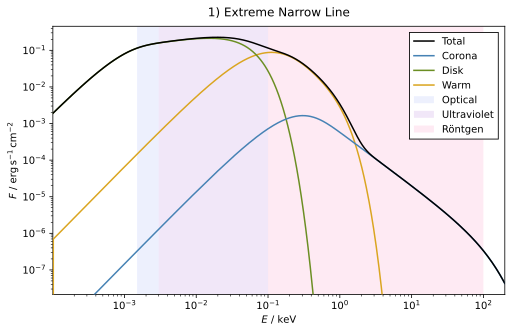


QSOSED Model Initialization...

Per Waveband Energy:

    Optical : 20.39 %
Ultraviolet : 54.20 %
    Röntgen :  0.99 %


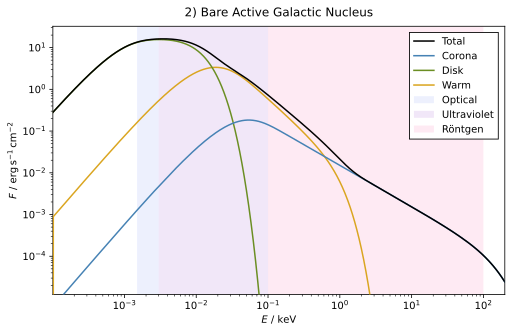


QSOSED Model Initialization...

Per Waveband Energy:

    Optical : 24.52 %
Ultraviolet : 52.23 %
    Röntgen :  0.20 %


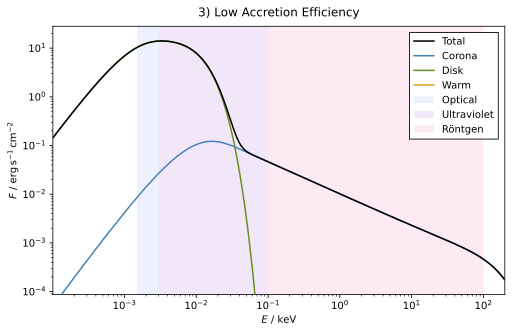

In [2]:
np.seterr(all='ignore')

df = pd.DataFrame()

df['source'] = ['SupEddAGN', 'Ark120', 'NGC5548']
df['description'] = ['1) Extreme Narrow Line',
                     '2) Bare Active Galactic Nucleus',
                     '3) Low Accretion Efficiency']
df['mbh'] = [2e6, 1.5e8, 6.5e7]
df['spin'] = [0.9, 0.83, 0.0]
df['mdot'] = [1.0, 0.1, 0.03]
df['dist_mpc'] = [180.0, 140.0, 72.0]
df['dist_cm'] = df['dist_mpc'] * 3.086e24

hotR = 10.0
warmR = 20.0

wavebands = {
    'Optical': (1.5e-3, 3e-3),
    'Ultraviolet': (3e-3, 0.1),
    'Röntgen': (0.1, 100.0)
}

colors = {'Optical': '#4361ee', 'Ultraviolet': '#7209b7', 'Röntgen': '#f72585'}

energies, fluxes, descriptions = [], [], []

for key, group in df.groupby(df.columns[0], sort=False):
    print('\nQSOSED Model Initialization...')
    model = SED(M = group['mbh'].item(),
                spin = group['spin'].item(),
                mdot = group['mdot'].item())
    model.hot_radius = hotR
    model.warm_radius = warmR
    energy = model.ENERGY_RANGE_KEV
    flux = model.total_flux(group['dist_cm'].item())
    energies.append(energy)
    fluxes.append(flux)
    descriptions.append(group['description'].item())
    warm = model.warm_flux(group['dist_cm'].item())
    disk = model.disk_flux(group['dist_cm'].item())
    corona = model.corona_flux(group['dist_cm'].item())
    bands = {}
    total = np.sum(flux)
    for band, (low, high) in wavebands.items():
        mask = (energy >= low) & (energy <= high)
        bands[band] = np.sum(flux[mask]) / total * 100.0
    print("\nPer Waveband Energy:\n")
    for key in bands.keys():
        print(f'{key:>11} : {bands[key]:>5.2f} %')
    plt.figure(figsize=(7, 4.5))
    plt.plot(energy, flux, color='k', lw=1.5, label='Total', zorder=40)
    plt.plot(energy, corona, color='steelblue', lw=1.5, label='Corona', zorder=30)
    plt.plot(energy, disk, color='olivedrab', lw=1.5, label='Disk', zorder=20)
    plt.plot(energy, warm, color='goldenrod', lw=1.5, label='Warm', zorder=10)
    for band, (low, high) in wavebands.items():
        plt.axvspan(low, high, facecolor=colors[band], edgecolor='none', alpha=0.1, label=f'{band}', zorder=0)
    plt.title(group['description'].item(), fontsize=12, pad=10)
    plt.xlabel(r'$E$ / keV')
    plt.ylabel(r'$F$ / erg$\,$s$^{-1}\,$cm$^{-2}$')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(energy.min(), energy.max())
    plt.ylim(flux.min() * 0.5, flux.max() * 2)
    leg = plt.legend(loc='upper right',
                     bbox_to_anchor=(1 - 0.01, 1 - 0.01 * 7 / 4.5),
                     frameon=True,
                     facecolor='white',
                     framealpha=1,
                     edgecolor='black',
                     borderpad=0.15)
    leg.get_frame().set_linewidth(0.85)
    leg.get_frame().set_boxstyle('square')
    plt.show()
    plt.close()

#### Comparison Display

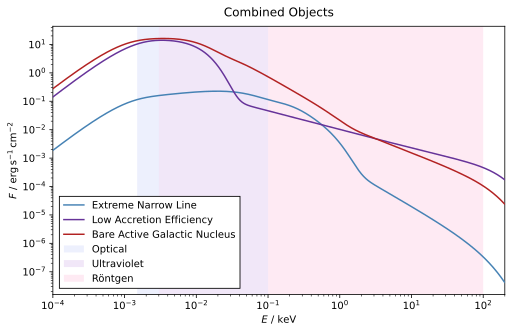

In [3]:
lines = ['steelblue', 'firebrick', 'rebeccapurple']

plt.figure(figsize=(7, 4.5))
for i in [0, 2, 1]:
    plt.plot(energies[i], fluxes[i], color=lines[i], lw=1.5, label=descriptions[i][3:], zorder=10)
for band, (low, high) in wavebands.items():
    plt.axvspan(low, high, facecolor=colors[band], edgecolor='none', alpha=0.1, label=f'{band}', zorder=0)
plt.xlim(1e-4, 2e2)
plt.title('Combined Objects', fontsize=12, pad=10)
plt.xlabel(r'$E$ / keV')
plt.ylabel(r'$F$ / erg$\,$s$^{-1}\,$cm$^{-2}$')
plt.xscale('log')
plt.yscale('log')
leg = plt.legend(loc='lower left',
                     bbox_to_anchor=(0.01, 0.01 * 7 / 4.5),
                     frameon=True,
                     facecolor='white',
                     framealpha=1,
                     edgecolor='black',
                     borderpad=0.15)
leg.get_frame().set_linewidth(0.85)
leg.get_frame().set_boxstyle('square')
plt.show()
plt.close()

##### 1) Extreme Narrow Line:
- strong warm component dominant in extreme ultraviolet and soft röntgen regimes
- less massive black hole with high accretion rate has naturally hotter disk
- accretion puffs up inner disk to optically thick warm corona that upscatters disk photons
##### 2) Bare Active Galactic Nucleus:
- standard spectral distribution
- driven by moderate accretion rate and more massive central engine
- slim disk is geometrically thin and optically thick
- production of characteristic big blue bump in ultraviolet
- smooth transition to röntgen aided by warm component as bridge
##### 3) Low Accretion Efficiency:
- very low accretion fails to stabilize disk near supermassive black hole
- advection dominated flow due to starvation of feeding matter
- accordingly no warm component and steep drop towards corona dominated spectrum
##### Global Effects:
- decreasing black hole masses increase the accretion disk temperature and therefore thermal spectrum peak
- larger spins allow smaller innermost stable orbits
- matter closer to central engine extents tail into higher energies and elevates radiative efficiency
- accretion flows dictates the shape of the active region
  - low rates starve inner disk and shift relative energy contribution to hot corona
  - intermediate rates lead to classic big blue bump ultraviolet dominated spectra
  - super eddington types smear bump into the röntgen range from puffed up warm component